# Nifty Regime Detection with Markov Switching Models (2010–2024)

This notebook builds an end-to-end latent-regime framework for Indian equities:
- Downloads Nifty 50, India VIX, Nifty Bank, and Nifty IT data
- Engineers rolling features on a strictly backward-looking basis
- Selects number of regimes K with BIC on 2010–2019
- Fits a Markov Switching model with switching mean and variance
- Uses filtered regime probabilities for live-style allocation
- Applies 0.1% transaction costs and a 5-trading-day minimum holding period
- Reports in-sample (2010–2019) vs out-of-sample (2020–2024) performance


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

plt.style.use('seaborn-v0_8-darkgrid')
pd.options.display.float_format = '{:,.6f}'.format


In [2]:
# 1) Data download (2010-01-01 to 2024-12-31)
TICKERS = {
    'nifty': '^NSEI',
    'india_vix': '^INDIAVIX',
    'bank': '^NSEBANK',
    'it': '^CNXIT'
}

start_date = '2010-01-01'
end_date = '2024-12-31'


def download_yfinance():
    raw = yf.download(
        list(TICKERS.values()),
        start=start_date,
        end=end_date,
        auto_adjust=False,
        progress=False,
        group_by='ticker',
    )
    if raw.empty:
        raise ValueError('yfinance returned empty data')

    close_df = pd.DataFrame({
        name: raw[ticker]['Close']
        for name, ticker in TICKERS.items()
    })
    close_df = close_df.ffill().dropna(how='any')
    if close_df.empty:
        raise ValueError('yfinance close prices empty after cleaning')
    return close_df


def download_github_fallback():
    base = 'https://raw.githubusercontent.com/Monarch-25/sector-roation-NSE/edc8589915f25e20a0bfc7572ba56691d4fd15f5/data/raw'
    urls = {
        'nifty': f'{base}/nifty_50.csv',
        'bank': f'{base}/nifty_bank.csv',
        'it': f'{base}/nifty_it.csv',
        'india_vix': f'{base}/macro/indiavix.csv',
    }

    series = {}
    for name, url in urls.items():
        tmp = pd.read_csv(url, skiprows=2, usecols=[0, 1])
        tmp.columns = ['Date', 'Close']
        tmp['Date'] = pd.to_datetime(tmp['Date'])
        tmp['Close'] = pd.to_numeric(tmp['Close'], errors='coerce')
        s = tmp.set_index('Date')['Close'].sort_index()
        series[name] = s

    close_df = pd.concat(series, axis=1)
    close_df = close_df.loc[start_date:end_date].ffill().dropna(how='any')
    return close_df


try:
    close_df = download_yfinance()
    data_source = 'yfinance'
except Exception as err:
    close_df = download_github_fallback()
    data_source = f'GitHub fallback ({err.__class__.__name__})'

print('Data source:', data_source)
close_df.head(), close_df.tail(), close_df.shape


Failed to get ticker '^NSEBANK' reason: Failed to perform, curl: (6) Could not resolve host: guce.yahoo.com. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.


Failed to get ticker '^CNXIT' reason: Failed to perform, curl: (6) Could not resolve host: guce.yahoo.com. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.


Failed to get ticker '^INDIAVIX' reason: Failed to perform, curl: (6) Could not resolve host: guce.yahoo.com. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.


$^INDIAVIX: possibly delisted; no timezone found


Failed to get ticker '^NSEI' reason: Failed to perform, curl: (6) Could not resolve host: guce.yahoo.com. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.


...


4 Failed downloads:


['^INDIAVIX', '^NSEI']: possibly delisted; no timezone found


['^NSEBANK', '^CNXIT']: DNSError('Failed to perform, curl: (6) Could not resolve host: guce.yahoo.com. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


Data source: GitHub fallback (ValueError)


(                  nifty         bank           it  india_vix
 Date                                                        
 2010-01-04 5,232.200195 9,112.244141 5,877.250000  23.639999
 2010-01-05 5,277.899902 9,192.043945 5,913.649902  22.270000
 2010-01-06 5,281.799805 9,222.892578 5,824.899902  22.120001
 2010-01-07 5,263.100098 9,192.843750 5,702.850098  22.500000
 2010-01-08 5,244.750000 9,160.593750 5,607.899902  22.570000,
                    nifty          bank            it  india_vix
 Date                                                           
 2024-12-24 23,727.650391 51,233.000000 43,668.898438  13.180000
 2024-12-26 23,750.199219 51,170.699219 43,664.250000  14.040000
 2024-12-27 23,813.400391 51,311.300781 43,721.398438  13.240000
 2024-12-30 23,644.900391 50,952.750000 43,971.449219  13.970000
 2024-12-31 23,644.800781 50,860.199219 43,337.800781  14.450000,
 (3696, 4))

In [3]:
# 2) Feature engineering (strictly rolling / backward-looking)
returns = close_df.pct_change()

features = pd.DataFrame(index=close_df.index)
features['nifty_ret'] = returns['nifty']
features['nifty_roll_mean_20'] = returns['nifty'].rolling(20).mean()
features['nifty_roll_vol_20'] = returns['nifty'].rolling(20).std()
features['nifty_momentum_60'] = close_df['nifty'].pct_change(60)
features['vix_chg_5'] = close_df['india_vix'].pct_change(5)
features['bank_it_corr_60'] = returns['bank'].rolling(60).corr(returns['it'])
features['bank_minus_it_20'] = returns['bank'].rolling(20).mean() - returns['it'].rolling(20).mean()

model_df = features.replace([np.inf, -np.inf], np.nan).dropna().copy()
model_df.head(), model_df.shape


(            nifty_ret  nifty_roll_mean_20  nifty_roll_vol_20  \
 Date                                                           
 2010-04-05   0.014724            0.002781           0.006223   
 2010-04-06  -0.000447            0.002675           0.006260   
 2010-04-07   0.001612            0.002409           0.006182   
 2010-04-08  -0.013061            0.001975           0.006942   
 2010-04-09   0.010802            0.002371           0.007217   
 
             nifty_momentum_60  vix_chg_5  bank_it_corr_60  bank_minus_it_20  
 Date                                                                         
 2010-04-05           0.026031  -0.040246         0.391283          0.002287  
 2010-04-06           0.016692  -0.081687         0.385078          0.002878  
 2010-04-07           0.017579  -0.125253         0.393344          0.002503  
 2010-04-08           0.007857   0.002516         0.380210          0.001821  
 2010-04-09           0.022308   0.046538         0.374492          0

In [4]:
# 3) Train/test split and BIC model selection (fit only on pre-2020)
train_end = '2019-12-31'

train_df = model_df.loc[:train_end].copy()
full_df = model_df.copy()

exog_cols = [
    'nifty_roll_mean_20',
    'nifty_roll_vol_20',
    'nifty_momentum_60',
    'vix_chg_5',
    'bank_it_corr_60',
    'bank_minus_it_20'
]

bic_rows = []
fit_results = {}

for k in [2, 3, 4, 5]:
    model = MarkovRegression(
        endog=train_df['nifty_ret'],
        exog=train_df[exog_cols],
        k_regimes=k,
        trend='c',
        switching_variance=True,
    )
    res = model.fit(disp=False, maxiter=1000)

    p = len(res.params)
    n = int(res.nobs)
    bic = -2 * res.llf + p * np.log(n)

    bic_rows.append({'K': k, 'llf': res.llf, 'params': p, 'nobs': n, 'BIC': bic})
    fit_results[k] = res

bic_df = pd.DataFrame(bic_rows).sort_values('K').reset_index(drop=True)
best_k = int(bic_df.loc[bic_df['BIC'].idxmin(), 'K'])
best_train_res = fit_results[best_k]

bic_df, best_k


/home/runner/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/home/runner/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/home/runner/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/home/runner/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


(   K          llf  params  nobs            BIC
 0  2 7,717.272252      18  2298 -15,295.228205
 1  3 7,781.242245      30  2298 -15,330.290656
 2  4 7,805.872675      44  2298 -15,271.194395
 3  5 7,831.412723      60  2298 -15,198.437778,
 3)

In [5]:
# 4) Decode regimes and transition dynamics
param_series = pd.Series(best_train_res.params, index=best_train_res.model.param_names)

regime_stats = []
for i in range(best_k):
    mu = param_series.get(f'const[{i}]', np.nan)
    if np.isnan(mu):
        mu = param_series.get(f'intercept[{i}]', np.nan)
    sigma2 = param_series.get(f'sigma2[{i}]', np.nan)
    regime_stats.append({'regime': i, 'mu': mu, 'sigma2': sigma2})

regime_stats = pd.DataFrame(regime_stats).set_index('regime')

P = best_train_res.regime_transition
if P.ndim == 3:
    P = P[:, :, 0]
P_df = pd.DataFrame(P, index=[f'from_{i}' for i in range(best_k)], columns=[f'to_{i}' for i in range(best_k)])

expected_duration = pd.Series(
    [1.0 / max(1e-9, (1 - P[i, i])) for i in range(best_k)],
    index=[f'regime_{i}' for i in range(best_k)],
    name='expected_duration_days'
)

regime_stats, P_df, expected_duration


(              mu   sigma2
 regime                   
 0       0.001051 0.000024
 1       0.005324 0.000037
 2      -0.008654 0.000054,
            to_0     to_1     to_2
 from_0 0.363250 0.399618 0.510107
 from_1 0.324658 0.331028 0.179829
 from_2 0.312093 0.269355 0.310064,
 regime_0   1.570474
 regime_1   1.494830
 regime_2   1.449409
 Name: expected_duration_days, dtype: float64)

In [6]:
# 5) Filtered probabilities over full sample (no refit): use train parameters on 2010-2024
full_model = MarkovRegression(
    endog=full_df['nifty_ret'],
    exog=full_df[exog_cols],
    k_regimes=best_k,
    trend='c',
    switching_variance=True,
)
full_filtered = full_model.filter(best_train_res.params)

probs = pd.DataFrame(
    np.asarray(full_filtered.filtered_marginal_probabilities),
    index=full_df.index,
    columns=[f'regime_{i}' for i in range(best_k)]
)

dominant_regime = probs.idxmax(axis=1).str.replace('regime_', '', regex=False).astype(int)

event_windows = {
    '2017 bull run': ('2017-01-01', '2017-12-31'),
    'Covid crash': ('2020-02-01', '2020-05-31'),
    '2022 rate hike correction': ('2022-01-01', '2022-10-31'),
}

event_map = []
for event, (s, e) in event_windows.items():
    m = probs.loc[s:e].mean()
    dom = int(m.idxmax().split('_')[-1])
    event_map.append({'event': event, 'dominant_regime': dom, 'avg_prob': m.max()})

event_map_df = pd.DataFrame(event_map)
event_map_df


/home/runner/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,event,dominant_regime,avg_prob
0,2017 bull run,0,0.438064
1,Covid crash,0,0.502101
2,2022 rate hike correction,0,0.412060


In [7]:
# 6) Probabilistic position sizing with 5-day minimum holding + 0.1% transaction costs
risk_on_regime = int(regime_stats['mu'].idxmax())
risk_off_regime = int(regime_stats['mu'].idxmin())

score = probs[f'regime_{risk_on_regime}'] - probs[f'regime_{risk_off_regime}']
equity_exposure = ((score + 1) / 2).clip(0, 1)

target_w = pd.DataFrame(index=full_df.index)
target_w['w_nifty'] = 0.50 * equity_exposure
target_w['w_bank'] = 0.30 * equity_exposure
target_w['w_it'] = 0.20 * equity_exposure
target_w['w_cash'] = 1.0 - equity_exposure

live_w = target_w.copy()
current_w = target_w.iloc[0].copy()
last_regime = int(dominant_regime.iloc[0])
bars_since_change = 999

for t in range(len(target_w)):
    if t == 0:
        live_w.iloc[t] = current_w
        continue

    proposed_w = target_w.iloc[t]
    new_regime = int(dominant_regime.iloc[t])
    regime_shift = new_regime != last_regime

    if regime_shift and bars_since_change >= 5:
        current_w = proposed_w
        last_regime = new_regime
        bars_since_change = 0
    else:
        bars_since_change += 1

    live_w.iloc[t] = current_w

asset_rets = returns.loc[live_w.index, ['nifty', 'bank', 'it']].fillna(0)
shifted_w = live_w[['w_nifty', 'w_bank', 'w_it']].shift(1).bfill()
gross_ret = (shifted_w.values * asset_rets.values).sum(axis=1)

tx_cost = 0.001
turnover = live_w[['w_nifty', 'w_bank', 'w_it', 'w_cash']].diff().abs().sum(axis=1).fillna(0)
net_ret = pd.Series(gross_ret, index=live_w.index) - tx_cost * turnover

bench_nifty = full_df['nifty_ret'].reindex(live_w.index).fillna(0)
bench_equal = asset_rets.mean(axis=1)

perf = pd.DataFrame({
    'strategy': net_ret,
    'nifty_buy_hold': bench_nifty,
    'equal_weight_3idx': bench_equal,
}, index=live_w.index)

cum_perf = (1 + perf).cumprod() - 1
perf.head(), perf.tail()


(            strategy  nifty_buy_hold  equal_weight_3idx
 Date                                                   
 2010-04-05  0.004140        0.014724           0.012151
 2010-04-06 -0.000791       -0.000447          -0.002418
 2010-04-07 -0.000577        0.001612          -0.001907
 2010-04-08 -0.005300       -0.013061          -0.008213
 2010-04-09  0.004905        0.010802           0.008419,
             strategy  nifty_buy_hold  equal_weight_3idx
 Date                                                   
 2024-12-24 -0.001386       -0.001086          -0.002124
 2024-12-26  0.000046        0.000950          -0.000124
 2024-12-27  0.001246        0.002661           0.002239
 2024-12-30 -0.002316       -0.007076          -0.002781
 2024-12-31 -0.001769       -0.000004          -0.005410)

In [8]:
# 7) Performance summary by period: train (2010-2019) vs test (2020-2024)
def perf_stats(series, ann_factor=252):
    s = series.dropna()
    if len(s) == 0:
        return pd.Series(dtype=float)
    total_return = (1 + s).prod() - 1
    ann_ret = (1 + total_return) ** (ann_factor / len(s)) - 1
    ann_vol = s.std() * np.sqrt(ann_factor)
    sharpe = ann_ret / ann_vol if ann_vol > 1e-12 else np.nan
    dd = ((1 + s).cumprod() / (1 + s).cumprod().cummax() - 1).min()
    return pd.Series({
        'Total Return': total_return,
        'Ann Return': ann_ret,
        'Ann Vol': ann_vol,
        'Sharpe': sharpe,
        'Max Drawdown': dd
    })

train_mask = perf.index <= train_end
test_mask = perf.index > train_end

summary_rows = []
for col in perf.columns:
    tr = perf_stats(perf.loc[train_mask, col])
    te = perf_stats(perf.loc[test_mask, col])
    summary_rows.append(pd.concat([tr.add_prefix('Train_'), te.add_prefix('Test_')], axis=0).rename(col))

summary_df = pd.DataFrame(summary_rows)
summary_df


,Train_Total Return,Train_Ann Return,Train_Ann Vol,Train_Sharpe,Train_Max Drawdown,Test_Total Return,Test_Ann Return,Test_Ann Vol,Test_Sharpe,Test_Max Drawdown
strategy,1.316647,0.096505,0.318146,0.303337,-0.290986,0.309732,0.056507,0.111313,0.507640,-0.177140
nifty_buy_hold,1.351006,0.098277,0.153332,0.640942,-0.278876,0.943123,0.144914,0.191074,0.758419,-0.384399
equal_weight_3idx,8.101805,0.274027,0.908125,0.301750,-0.426061,1.104496,0.163674,0.201632,0.811747,-0.393465


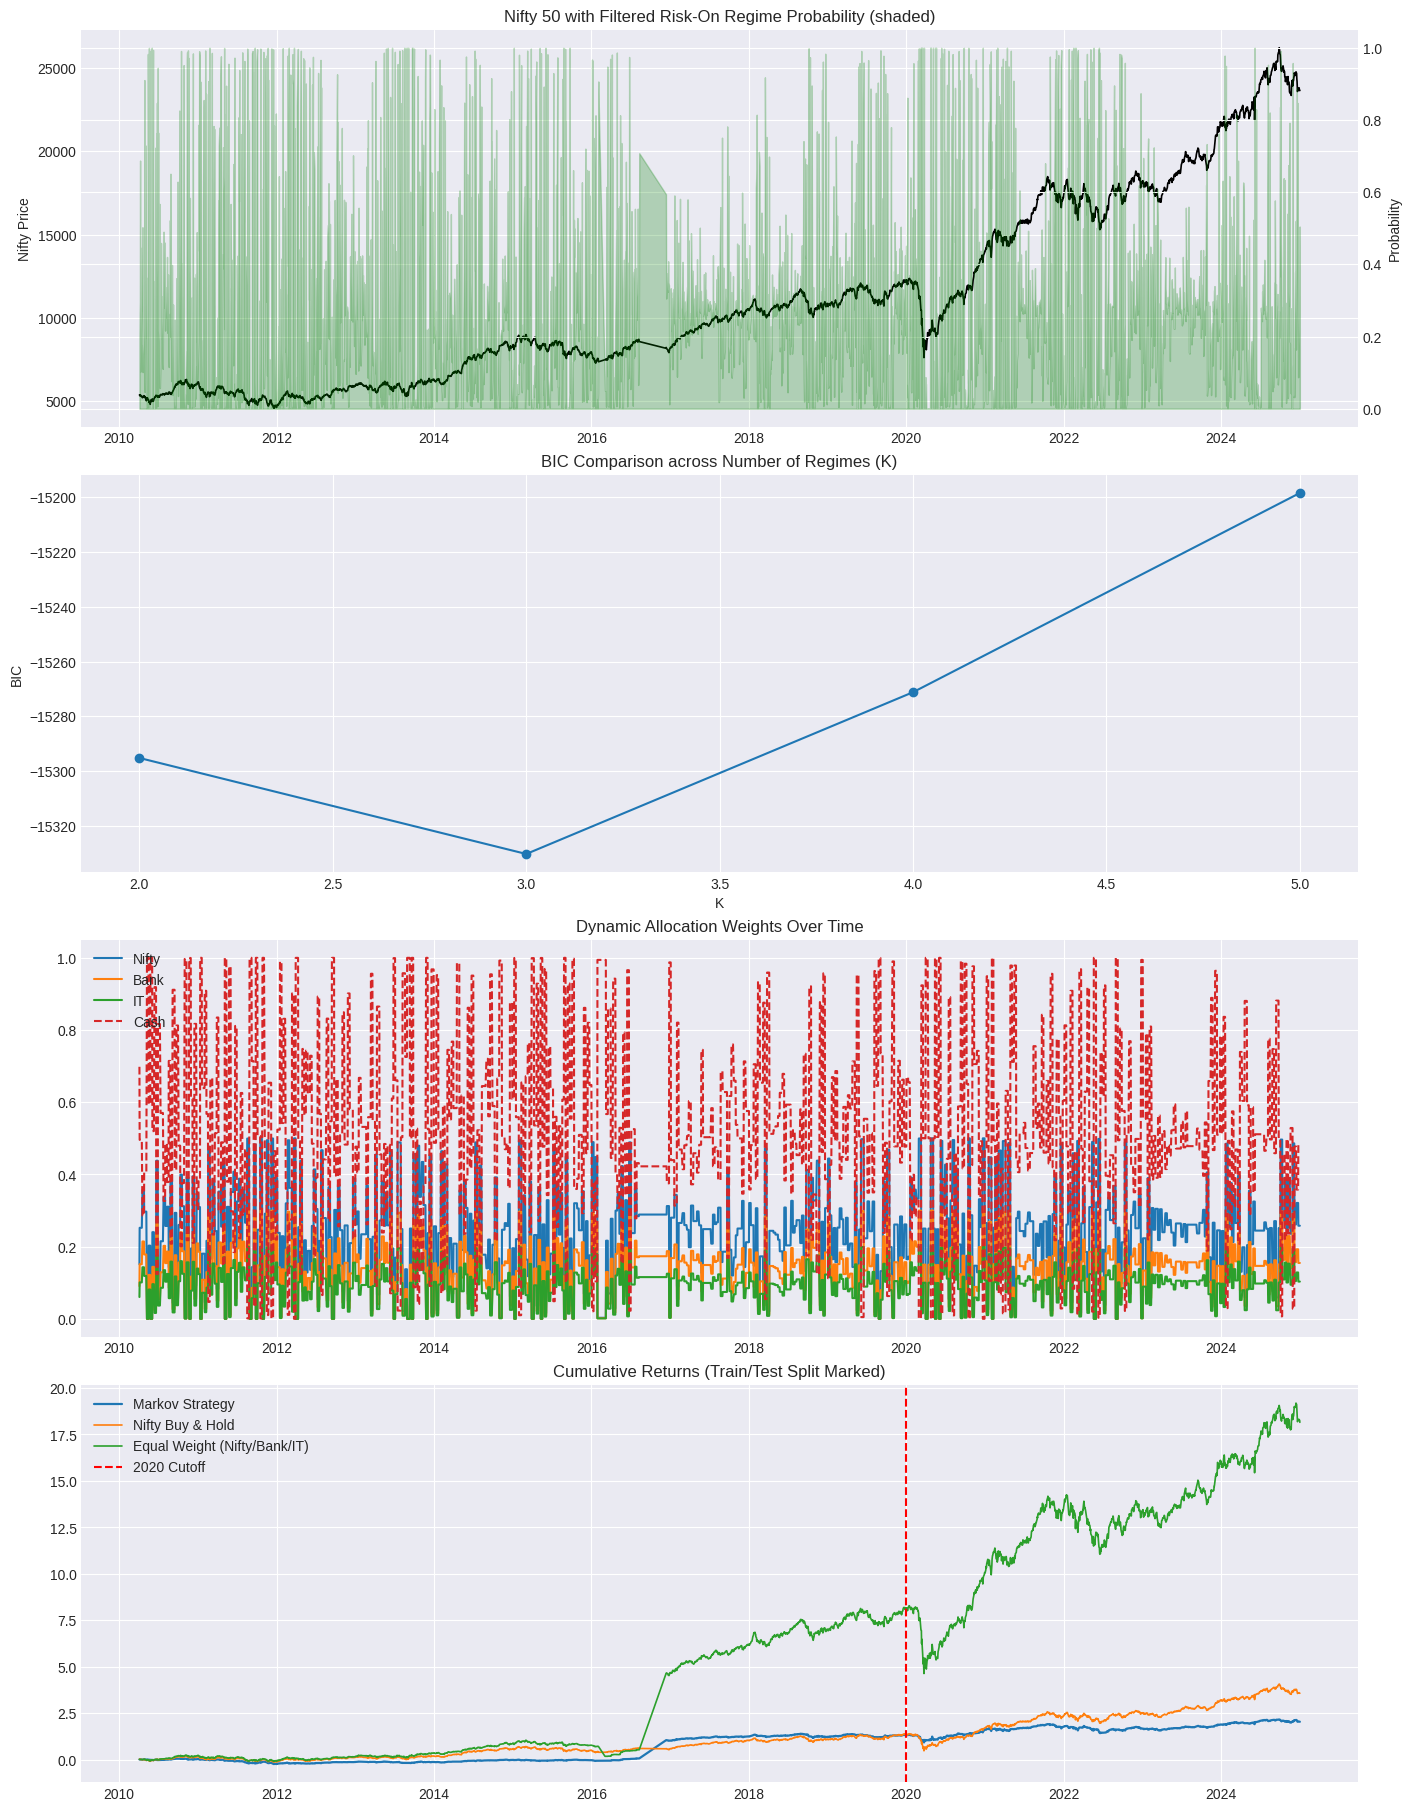

In [9]:
# 8) Visualisations
fig, axes = plt.subplots(4, 1, figsize=(14, 18), constrained_layout=True)

ax = axes[0]
ax.plot(close_df.loc[probs.index, 'nifty'], color='black', lw=1.2, label='Nifty 50 Close')
ax2 = ax.twinx()
ax2.fill_between(
    probs.index,
    0,
    probs[f'regime_{risk_on_regime}'],
    color='green',
    alpha=0.25,
    label=f'Filtered P(Regime {risk_on_regime})'
)
ax.set_title('Nifty 50 with Filtered Risk-On Regime Probability (shaded)')
ax.set_ylabel('Nifty Price')
ax2.set_ylabel('Probability')

axes[1].plot(bic_df['K'], bic_df['BIC'], marker='o')
axes[1].set_title('BIC Comparison across Number of Regimes (K)')
axes[1].set_xlabel('K')
axes[1].set_ylabel('BIC')

axes[2].plot(live_w.index, live_w['w_nifty'], label='Nifty')
axes[2].plot(live_w.index, live_w['w_bank'], label='Bank')
axes[2].plot(live_w.index, live_w['w_it'], label='IT')
axes[2].plot(live_w.index, live_w['w_cash'], label='Cash', linestyle='--')
axes[2].set_title('Dynamic Allocation Weights Over Time')
axes[2].legend(loc='upper left')

axes[3].plot(cum_perf.index, cum_perf['strategy'], label='Markov Strategy', lw=1.6)
axes[3].plot(cum_perf.index, cum_perf['nifty_buy_hold'], label='Nifty Buy & Hold', lw=1.2)
axes[3].plot(cum_perf.index, cum_perf['equal_weight_3idx'], label='Equal Weight (Nifty/Bank/IT)', lw=1.2)
axes[3].axvline(pd.Timestamp('2020-01-01'), color='red', linestyle='--', label='2020 Cutoff')
axes[3].set_title('Cumulative Returns (Train/Test Split Marked)')
axes[3].legend(loc='upper left')

plt.show()


In [10]:
# 9) Key outputs
print(f'Chosen number of regimes (K): {best_k}')
print('\nRegime parameters (mu, sigma^2):')
display(regime_stats)
print('\nTransition probability matrix:')
display(P_df)
print('\nExpected regime duration (days):')
display(expected_duration.to_frame())
print('\nKnown-event regime mapping:')
display(event_map_df)
print('\nPerformance summary (train/test):')
display(summary_df)


Chosen number of regimes (K): 3

Regime parameters (mu, sigma^2):


,mu,sigma2
regime,,
0,0.001051,0.000024
1,0.005324,0.000037
2,-0.008654,0.000054



Transition probability matrix:


,to_0,to_1,to_2
from_0,0.363250,0.399618,0.510107
from_1,0.324658,0.331028,0.179829
from_2,0.312093,0.269355,0.310064



Expected regime duration (days):


,expected_duration_days
regime_0,1.570474
regime_1,1.494830
regime_2,1.449409



Known-event regime mapping:


,event,dominant_regime,avg_prob
0,2017 bull run,0,0.438064
1,Covid crash,0,0.502101
2,2022 rate hike correction,0,0.412060



Performance summary (train/test):


,Train_Total Return,Train_Ann Return,Train_Ann Vol,Train_Sharpe,Train_Max Drawdown,Test_Total Return,Test_Ann Return,Test_Ann Vol,Test_Sharpe,Test_Max Drawdown
strategy,1.316647,0.096505,0.318146,0.303337,-0.290986,0.309732,0.056507,0.111313,0.507640,-0.177140
nifty_buy_hold,1.351006,0.098277,0.153332,0.640942,-0.278876,0.943123,0.144914,0.191074,0.758419,-0.384399
equal_weight_3idx,8.101805,0.274027,0.908125,0.301750,-0.426061,1.104496,0.163674,0.201632,0.811747,-0.393465
